In [1]:
import torch
from PIL import Image
import matplotlib.pyplot as plt

from UNET_model import UNET, DoubleConv

import albumentations as A
from albumentations.pytorch import ToTensorV2

import cv2
import numpy as np

In [2]:
TESTING_IMAGES_PATH = "C:\\Users\\colwy\\Documents\\SFU\Spring2025\\CMPT 419\\Project\\2025_1_project_06\\src\\datasets\\datasets\\kmader\\skin-cancer-mnist-ham10000\\versions\\2\\HAM10000_images_test"
VALIDATION_IMAGES_PATH = "C:\\Users\\colwy\\Documents\\SFU\Spring2025\\CMPT 419\\Project\\2025_1_project_06\\src\\datasets\\datasets\\kmader\\skin-cancer-mnist-ham10000\\versions\\2\\HAM10000_images_validation"
TESTING_MASKS_PATH = "C:\\Users\\colwy\\Documents\\SFU\Spring2025\\CMPT 419\\Project\\2025_1_project_06\\src\\datasets\\datasets\\tschandl\\ham10000-lesion-segmentations\\versions\\1\\HAM10000_segmentations_lesion_tschandl_test"
VALIDATION_MASKS_PATH = "C:\\Users\\colwy\\Documents\\SFU\Spring2025\\CMPT 419\\Project\\2025_1_project_06\\src\\datasets\\datasets\\tschandl\\ham10000-lesion-segmentations\\versions\\1\\HAM10000_segmentations_lesion_tschandl_validation"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMAGE_HEIGHT = 192
IMAGE_WIDTH = 256

def get_validation_transformations():
    return A.Compose([
        A.Resize(IMAGE_HEIGHT, IMAGE_WIDTH),
        A.Normalize(mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0), max_pixel_value=255.0),
        ToTensorV2()
    ])

In [4]:
image_path = "C:\\Users\\colwy\\Documents\\SFU\\Spring2025\\CMPT 419\\Project\\2025_1_project_06\\src\\datasets\\datasets\\kmader\\skin-cancer-mnist-ham10000\\versions\\2\\HAM10000_images_validation\\ISIC_0025119.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

transform = get_validation_transformations()
transformed = transform(image=image)
input_tensor = transformed["image"].unsqueeze(0)

In [5]:
test_model = UNET(in_channels=3, out_channels=1)
test_model.load_state_dict(torch.load('segmentation_model.pth'))
test_model.eval()

with torch.no_grad():
    output = test_model(input_tensor)
    output = torch.sigmoid(output)  # Sigmoid since it's binary
    predicted_mask = (output.squeeze().cpu().numpy() > 0.5).astype(np.uint8)

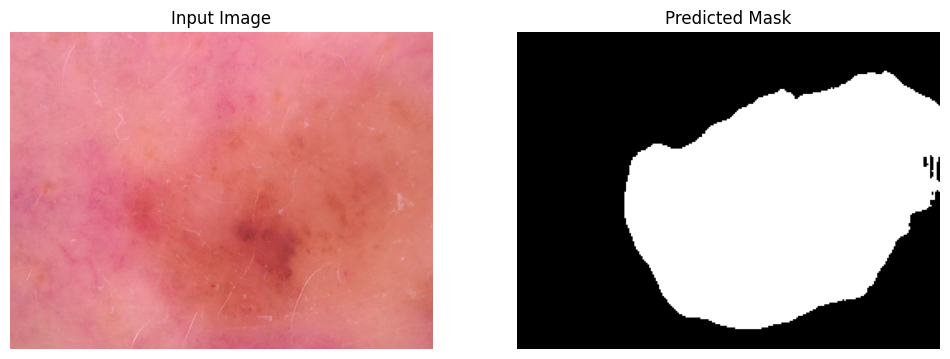

In [6]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(predicted_mask, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.show()